# 07 Bulk DP d0 vs d2 Trafficking Marker Dynamics

Use the Von Hoesslin Sci Immuno 2022 bulk RNA-seq data (`GSE208097`) to inspect DP-cell dynamics for the trafficking markers used in notebook 06. The analysis compares the DP d0 baseline (`DP_nr_d0`) against both DP d2 groups (`DP_wt_d2` and `DP_ova_d2`).


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import sys
sys.path.append("/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.paths import RESULTS_DIR

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300


/tmp/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-an9omh63 because there was an issue with the default path (/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Input Files and Marker Sets


In [2]:
VON_HOESSLIN_REPO = Path("/home/dk5299/Projects_31926/RNA-seq/Von_Hoesslin_Sci_Immuno_2022")

count_file = VON_HOESSLIN_REPO / "count matrix" / "GSE208097_count_matrix_compiled"
metadata_file = VON_HOESSLIN_REPO / "results" / "tables" / "00_loading" / "00_sample_metadata.tsv"
deseq_file = VON_HOESSLIN_REPO / "results" / "tables" / "02_deseq" / "02_deseq_results_compiled.tsv"

output_dir = RESULTS_DIR / "07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics"
output_dir.mkdir(parents=True, exist_ok=True)

marker_sets = {
    "egress": ["S1pr1", "Klf2","S1pr5", "Ccr7"],
    "gut_homing": ["Ccr9", "Itgb7"],
    "inflammatory_trafficking": ["Cxcr3", "Ccr5"],
    "trafficking_all": ["S1pr1", "Klf2", "Cxcr3", "Ccr5", "Ccr9", "Itgb7"],
    "combined_dp_markers": ["S1pr1", "Klf2", "Cd69", "Itgae", "Ccr9", "Cxcr6", "Hic1", "Klrg1", "Ccr7"],
}

marker_genes = list(dict.fromkeys(gene for genes in marker_sets.values() for gene in genes))
marker_genes


['S1pr1',
 'Klf2',
 'S1pr5',
 'Ccr7',
 'Ccr9',
 'Itgb7',
 'Cxcr3',
 'Ccr5',
 'Cd69',
 'Itgae',
 'Cxcr6',
 'Hic1',
 'Klrg1']

## Custom Genes to Edit for Pretty Dot Plot

Change `custom_genes` here. The final section of this notebook uses this list to make the pretty expression dot plot and DESeq2 log2FC layout.

In [3]:
custom_panel_name = "dp_egress_residency_custom"

custom_genes = [
    "Ccr7",
    "S1pr1",
    "Klf2",
    "Cd69",
    "Itgae",
    "Ccr9",
    "Cxcr6",
]

# A sample is counted as detected for dot-size scaling when CPM is above this threshold.
custom_detection_cpm_threshold = 1.0

custom_genes


['Ccr7', 'S1pr1', 'Klf2', 'Cd69', 'Itgae', 'Ccr9', 'Cxcr6']

## Load Bulk Counts and Metadata


In [4]:
counts_annotated = pd.read_csv(count_file, sep="	")
metadata = pd.read_csv(metadata_file, sep="	")
deseq = pd.read_csv(deseq_file, sep="	")

counts_annotated.shape, metadata.shape, deseq.shape


((54930, 38), (36, 9), (16953, 86))

In [5]:
dp_metadata = metadata[
    metadata["subpopulation"].eq("DP")
    & metadata["condition"].isin(["DP_nr_d0", "DP_wt_d2", "DP_ova_d2"])
].copy()

condition_order = ["DP_nr_d0", "DP_wt_d2", "DP_ova_d2"]
dp_metadata["condition"] = pd.Categorical(dp_metadata["condition"], categories=condition_order, ordered=True)
dp_metadata = dp_metadata.sort_values(["condition", "replicate"])

dp_samples = dp_metadata["sample_id"].tolist()
dp_metadata


,sample_id,geo_accession,raw_column,batch,subpopulation,group_code,timepoint,replicate,condition
0,DP_nr_d0_1,GSM6337029,L1_S1,A,DP,nr,d0,1,DP_nr_d0
1,DP_nr_d0_2,GSM6337030,L2_S2,A,DP,nr,d0,2,DP_nr_d0
2,DP_nr_d0_3,GSM6337031,L3_S3,A,DP,nr,d0,3,DP_nr_d0
3,DP_wt_d2_1,GSM6337032,L6_S6,A,DP,wt,d2,1,DP_wt_d2
4,DP_wt_d2_2,GSM6337033,L7_S7,A,DP,wt,d2,2,DP_wt_d2
5,DP_wt_d2_3,GSM6337034,L8_S8,A,DP,wt,d2,3,DP_wt_d2
6,DP_wt_d2_4,GSM6337035,L9_S9,A,DP,wt,d2,4,DP_wt_d2
7,DP_wt_d2_5,GSM6337036,L10_S10,A,DP,wt,d2,5,DP_wt_d2
8,DP_ova_d2_1,GSM6337037,L11_S11,A,DP,ova,d2,1,DP_ova_d2
9,DP_ova_d2_2,GSM6337038,L12_S12,A,DP,ova,d2,2,DP_ova_d2


## Normalize Counts for Visualization

The DE statistics below come from the existing DESeq2 workflow. For expression dynamics and module summaries, counts are normalized as log2(CPM + 1) across the DP d0/d2 samples.


In [6]:
count_matrix = counts_annotated.set_index("gene_name")[dp_samples]
count_matrix = count_matrix.groupby(level=0).sum()

missing_markers = sorted(set(marker_genes).difference(count_matrix.index))
if missing_markers:
    print("Missing marker genes:", missing_markers)

marker_counts = count_matrix.loc[[gene for gene in marker_genes if gene in count_matrix.index]].copy()
library_sizes = count_matrix.sum(axis=0)
log2_cpm = np.log2(marker_counts.div(library_sizes, axis=1) * 1_000_000 + 1)

log2_cpm.head()


,DP_nr_d0_1,DP_nr_d0_2,DP_nr_d0_3,DP_wt_d2_1,DP_wt_d2_2,DP_wt_d2_3,DP_wt_d2_4,DP_wt_d2_5,DP_ova_d2_1,DP_ova_d2_2,DP_ova_d2_3,DP_ova_d2_4
gene_name,,,,,,,,,,,,
S1pr1,3.067033,0.000000,2.232949,2.740530,4.182911,3.205294,3.335483,3.966959,3.795968,3.837026,3.877713,3.544812
Klf2,4.277634,6.150068,4.612075,4.396540,5.849534,5.362799,6.816009,5.860001,5.631584,5.925468,5.555391,6.894601
S1pr5,0.000000,0.000000,0.000000,0.079746,0.000000,0.000000,0.000000,0.000000,0.079003,0.000000,0.000000,0.000000
Ccr7,1.767336,1.097681,0.518613,4.376943,6.978069,4.516562,5.091739,4.594650,6.012325,5.474539,6.184738,5.000985
Ccr9,7.878543,6.044086,8.089679,7.445260,7.463709,6.720896,6.614155,6.913737,6.942893,6.636864,7.849937,6.569865


In [7]:
expr_long = (
    log2_cpm.reset_index(names="gene")
    .melt(id_vars="gene", var_name="sample_id", value_name="log2_cpm")
    .merge(dp_metadata, on="sample_id", how="left")
)

expr_summary = (
    expr_long.groupby(["gene", "condition"], observed=True)["log2_cpm"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
)

expr_file = output_dir / "07_bulk_dp_d0_d2_marker_log2cpm_by_sample.tsv"
summary_file = output_dir / "07_bulk_dp_d0_d2_marker_log2cpm_summary.tsv"
expr_long.to_csv(expr_file, sep="	", index=False)
expr_summary.to_csv(summary_file, sep="	", index=False)

print("Saved:", expr_file)
print("Saved:", summary_file)
expr_summary


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_bulk_dp_d0_d2_marker_log2cpm_by_sample.tsv
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_bulk_dp_d0_d2_marker_log2cpm_summary.tsv


,gene,condition,mean,median,std,count
0,Ccr5,DP_nr_d0,8.613120,8.687139,0.158423,3
1,Ccr5,DP_wt_d2,7.923613,7.971986,0.371644,5
2,Ccr5,DP_ova_d2,7.875175,8.106964,0.732241,4
3,Ccr7,DP_nr_d0,1.127877,1.097681,0.624909,3
4,Ccr7,DP_wt_d2,5.111593,4.594650,1.077628,5
5,Ccr7,DP_ova_d2,5.668147,5.743432,0.537870,4
6,Ccr9,DP_nr_d0,7.337436,7.878543,1.125038,3
7,Ccr9,DP_wt_d2,7.031551,6.913737,0.400787,5
8,Ccr9,DP_ova_d2,6.999890,6.789878,0.589502,4
9,Cd69,DP_nr_d0,9.310488,9.369939,0.214267,3


## Join Existing DESeq2 d2-vs-d0 Statistics


In [8]:
contrast_prefixes = ["DP_d2_wt_vs_d0_nr", "DP_d2_ova_vs_d0_nr"]
stat_columns = ["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj", "significant"]

rows = []
for _, row in deseq[deseq["gene_name"].isin(marker_genes)].iterrows():
    for contrast in contrast_prefixes:
        out = {
            "gene_id": row["gene_id"],
            "gene": row["gene_name"],
            "contrast": contrast,
        }
        for stat in stat_columns:
            out[stat] = row.get(f"{contrast}__{stat}", np.nan)
        rows.append(out)

deseq_markers = pd.DataFrame(rows)
deseq_marker_file = output_dir / "07_bulk_dp_d0_d2_marker_deseq_stats.tsv"
deseq_markers.to_csv(deseq_marker_file, sep="	", index=False)

print("Saved:", deseq_marker_file)
deseq_markers.sort_values(["contrast", "gene"])


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_bulk_dp_d0_d2_marker_deseq_stats.tsv


,gene_id,gene,contrast,baseMean,log2FoldChange,lfcSE,pvalue,padj,significant
25,ENSMUSG00000079227,Ccr5,DP_d2_ova_vs_d0_nr,5138.924771,-0.215352,0.278870,4.197924e-01,7.368121e-01,False
11,ENSMUSG00000037944,Ccr7,DP_d2_ova_vs_d0_nr,570.179274,5.618728,0.512049,2.071347e-29,1.795127e-26,True
5,ENSMUSG00000029530,Ccr9,DP_d2_ova_vs_d0_nr,2619.497457,-0.061046,0.398181,8.572929e-01,9.654129e-01,False
9,ENSMUSG00000030156,Cd69,DP_d2_ova_vs_d0_nr,10797.087606,0.381729,0.191740,4.119717e-02,1.875063e-01,False
21,ENSMUSG00000050232,Cxcr3,DP_d2_ova_vs_d0_nr,2213.091177,-0.664899,0.295038,1.815672e-02,1.028067e-01,False
19,ENSMUSG00000048521,Cxcr6,DP_d2_ova_vs_d0_nr,19567.991655,-0.563307,0.242450,1.581317e-02,9.259757e-02,False
13,ENSMUSG00000043099,Hic1,DP_d2_ova_vs_d0_nr,1092.394213,0.126505,0.377233,7.259057e-01,9.177080e-01,False
3,ENSMUSG00000005947,Itgae,DP_d2_ova_vs_d0_nr,11536.813810,-0.222859,0.147503,1.262427e-01,3.867609e-01,False
1,ENSMUSG00000001281,Itgb7,DP_d2_ova_vs_d0_nr,9872.996635,-0.382749,0.096631,6.859632e-05,9.792922e-04,False
23,ENSMUSG00000055148,Klf2,DP_d2_ova_vs_d0_nr,1017.065092,1.141424,0.552970,1.552676e-02,9.142918e-02,False


## Bulk Module Scores

For each marker set, the sample-level module score is the mean of gene-wise z-scored log2CPM values across DP d0/d2 samples. This is a descriptive bulk expression score, not a Scanpy control-gene-adjusted score.


In [9]:
gene_z = log2_cpm.sub(log2_cpm.mean(axis=1), axis=0).div(log2_cpm.std(axis=1).replace(0, np.nan), axis=0)

module_scores = []
for module, genes in marker_sets.items():
    present = [gene for gene in genes if gene in gene_z.index]
    if not present:
        continue
    module_score = gene_z.loc[present].mean(axis=0)
    module_scores.append(
        pd.DataFrame(
            {
                "sample_id": module_score.index,
                "module": module,
                "module_score": module_score.values,
                "genes_present": ";".join(present),
            }
        )
    )

module_scores = pd.concat(module_scores, ignore_index=True).merge(dp_metadata, on="sample_id", how="left")
module_summary = (
    module_scores.groupby(["module", "condition"], observed=True)["module_score"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
)

module_file = output_dir / "07_bulk_dp_d0_d2_module_scores_by_sample.tsv"
module_summary_file = output_dir / "07_bulk_dp_d0_d2_module_score_summary.tsv"
module_scores.to_csv(module_file, sep="	", index=False)
module_summary.to_csv(module_summary_file, sep="	", index=False)

print("Saved:", module_file)
print("Saved:", module_summary_file)
module_summary


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_bulk_dp_d0_d2_module_scores_by_sample.tsv
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_bulk_dp_d0_d2_module_score_summary.tsv


,module,condition,mean,median,std,count
0,combined_dp_markers,DP_nr_d0,-0.208023,-0.051411,0.309562,3
1,combined_dp_markers,DP_wt_d2,0.169974,0.126639,0.252523,5
2,combined_dp_markers,DP_ova_d2,-0.056451,0.008137,0.638237,4
3,egress,DP_nr_d0,-0.969072,-1.025434,0.127272,3
4,egress,DP_wt_d2,0.207310,0.181176,0.254339,5
5,egress,DP_ova_d2,0.467666,0.360199,0.290819,4
6,gut_homing,DP_nr_d0,0.952949,1.414480,0.866732,3
7,gut_homing,DP_wt_d2,-0.285032,-0.221967,0.242918,5
8,gut_homing,DP_ova_d2,-0.358422,-0.444671,0.742889,4
9,inflammatory_trafficking,DP_nr_d0,1.074469,1.330775,0.578705,3


## Plot Marker Dynamics


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_bulk_dp_d0_d2_marker_expression.png


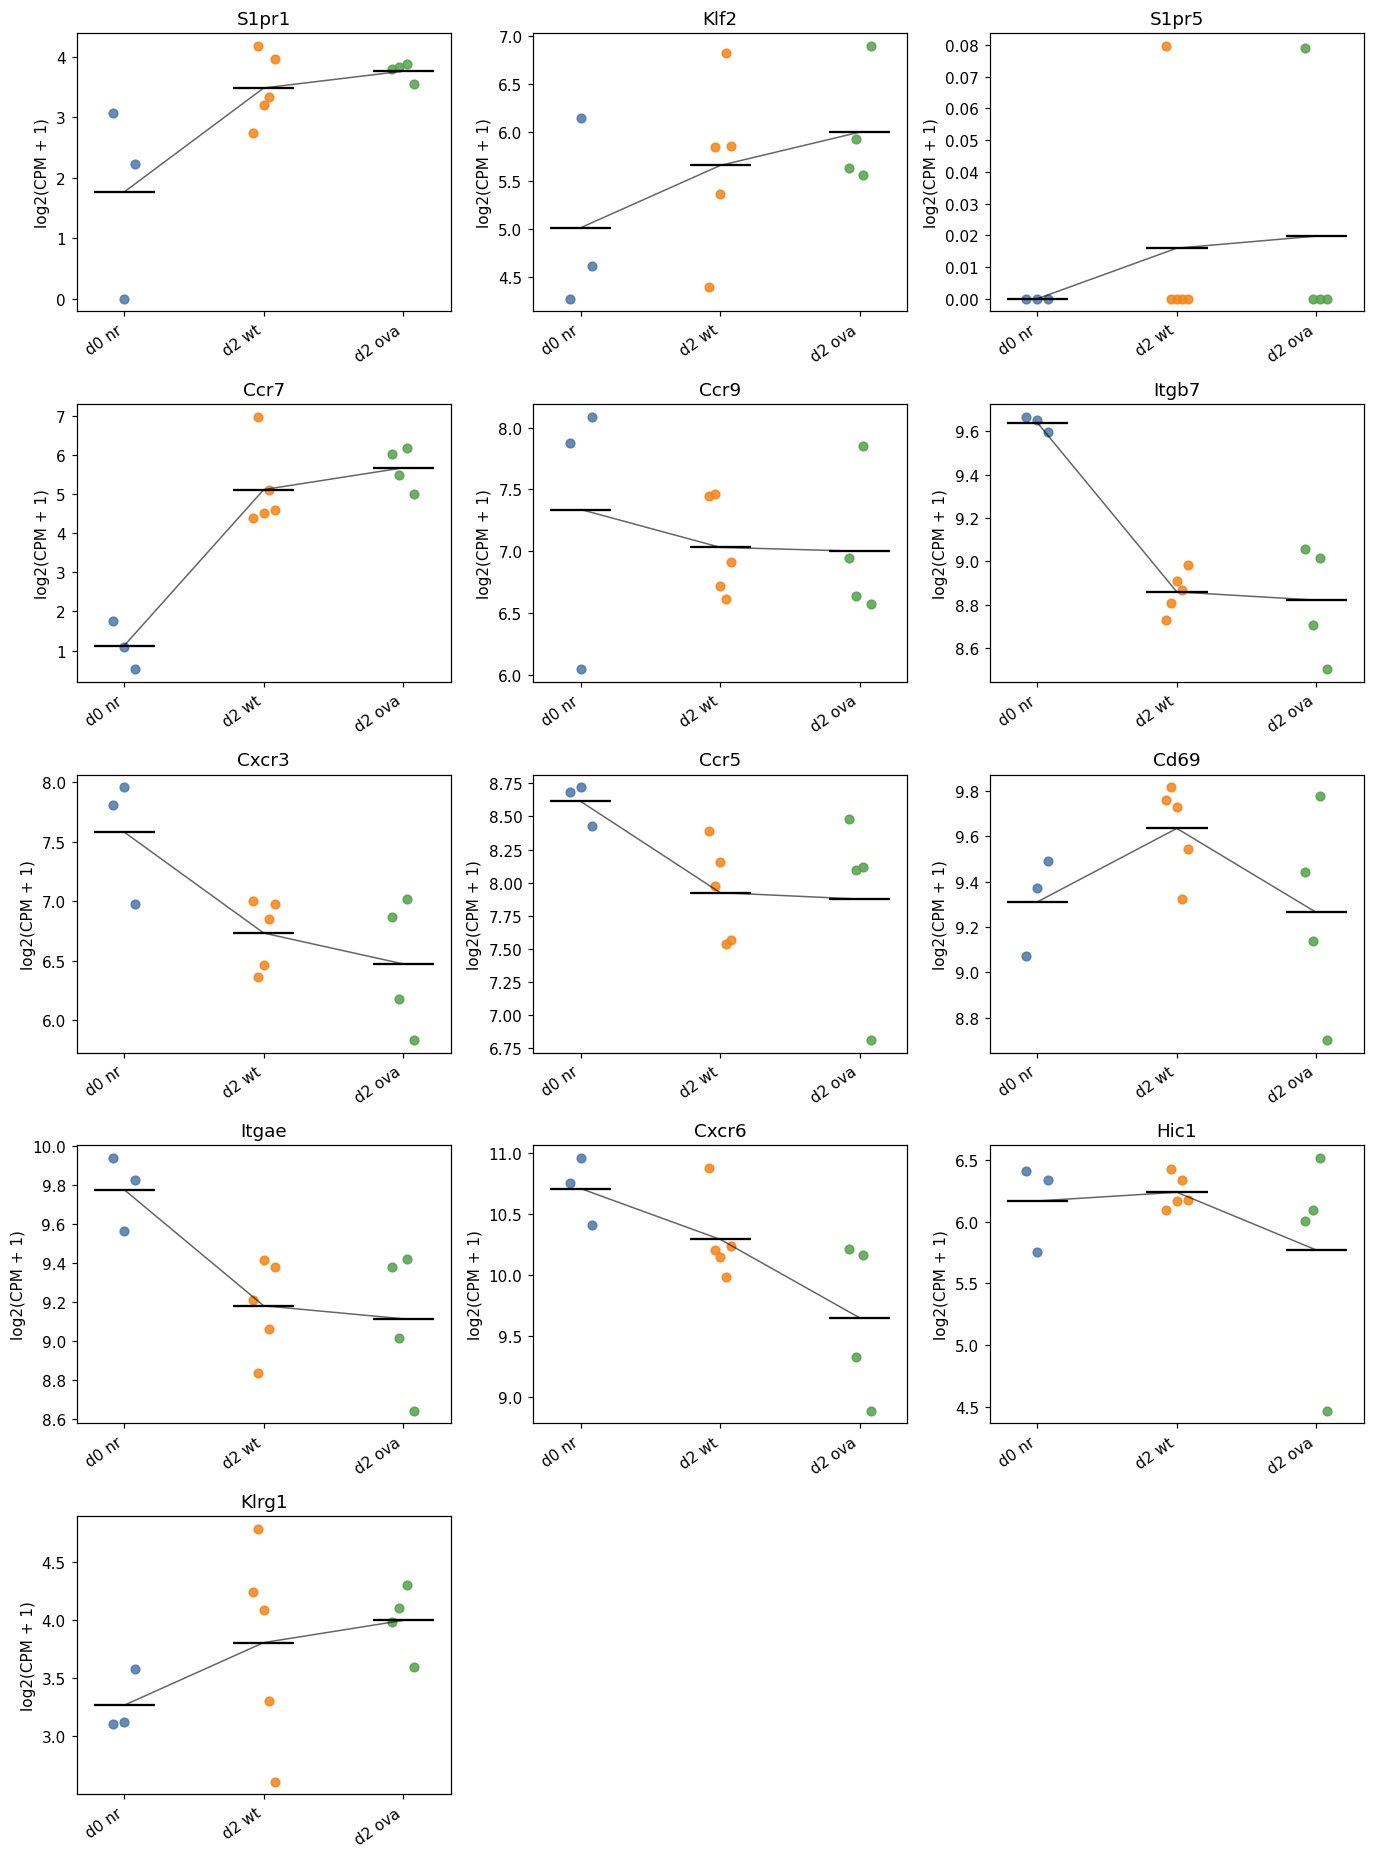

In [10]:
condition_colors = {
    "DP_nr_d0": "#4c78a8",
    "DP_wt_d2": "#f58518",
    "DP_ova_d2": "#54a24b",
}

n_genes = len(marker_genes)
ncols = 3
nrows = int(np.ceil(n_genes / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows), squeeze=False)

for ax, gene in zip(axes.ravel(), marker_genes):
    gene_df = expr_long[expr_long["gene"].eq(gene)].copy()
    for x, condition in enumerate(condition_order):
        values = gene_df.loc[gene_df["condition"].astype(str).eq(condition), "log2_cpm"].values
        jitter = np.linspace(-0.08, 0.08, len(values)) if len(values) > 1 else np.array([0])
        ax.scatter(np.full(len(values), x) + jitter, values, color=condition_colors[condition], s=32, alpha=0.85)
        if len(values):
            ax.hlines(values.mean(), x - 0.22, x + 0.22, color="black", linewidth=1.5)
    means = [gene_df.loc[gene_df["condition"].astype(str).eq(condition), "log2_cpm"].mean() for condition in condition_order]
    ax.plot(range(len(condition_order)), means, color="black", linewidth=1, alpha=0.6)
    ax.set_title(gene)
    ax.set_xticks(range(len(condition_order)))
    ax.set_xticklabels(["d0 nr", "d2 wt", "d2 ova"], rotation=35, ha="right")
    ax.set_ylabel("log2(CPM + 1)")

for ax in axes.ravel()[n_genes:]:
    ax.axis("off")

fig.tight_layout()
marker_plot_file = output_dir / "07_bulk_dp_d0_d2_marker_expression.png"
fig.savefig(marker_plot_file, bbox_inches="tight")
print("Saved:", marker_plot_file)


## Plot Module Dynamics


/tmp/ipykernel_4174556/3382604240.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values_by_condition, labels=["d0 nr", "d2 wt", "d2 ova"], showfliers=False)
/tmp/ipykernel_4174556/3382604240.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values_by_condition, labels=["d0 nr", "d2 wt", "d2 ova"], showfliers=False)
/tmp/ipykernel_4174556/3382604240.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values_by_condition, labels=["d0 nr", "d2 wt", "d2 ova"], showfliers=False)
/tmp/ipykernel_4174556/3382604240.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplo

Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_bulk_dp_d0_d2_module_scores.png


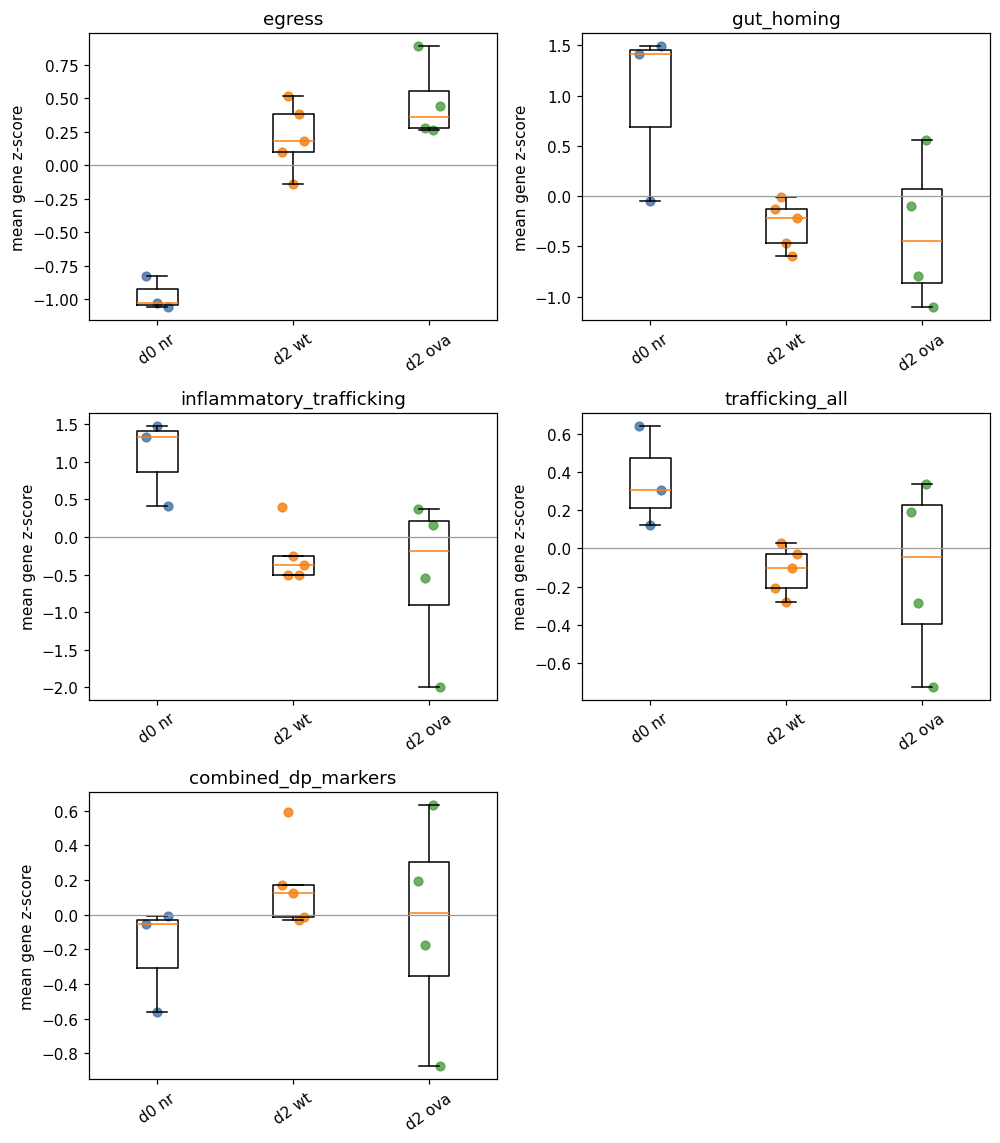

In [11]:
modules = list(marker_sets.keys())
ncols = 2
nrows = int(np.ceil(len(modules) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.5 * nrows), squeeze=False)

for ax, module in zip(axes.ravel(), modules):
    module_df = module_scores[module_scores["module"].eq(module)].copy()
    values_by_condition = [
        module_df.loc[module_df["condition"].astype(str).eq(condition), "module_score"].values
        for condition in condition_order
    ]
    ax.boxplot(values_by_condition, labels=["d0 nr", "d2 wt", "d2 ova"], showfliers=False)
    for x, (condition, values) in enumerate(zip(condition_order, values_by_condition), start=1):
        jitter = np.linspace(-0.08, 0.08, len(values)) if len(values) > 1 else np.array([0])
        ax.scatter(np.full(len(values), x) + jitter, values, color=condition_colors[condition], s=32, alpha=0.85)
    ax.axhline(0, color="0.6", linewidth=0.8)
    ax.set_title(module)
    ax.set_ylabel("mean gene z-score")
    ax.tick_params(axis="x", rotation=35)

for ax in axes.ravel()[len(modules):]:
    ax.axis("off")

fig.tight_layout()
module_plot_file = output_dir / "07_bulk_dp_d0_d2_module_scores.png"
fig.savefig(module_plot_file, bbox_inches="tight")
print("Saved:", module_plot_file)


## Plot DESeq2 Log2 Fold Changes


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_bulk_dp_d0_d2_marker_deseq_lfc_heatmap.png


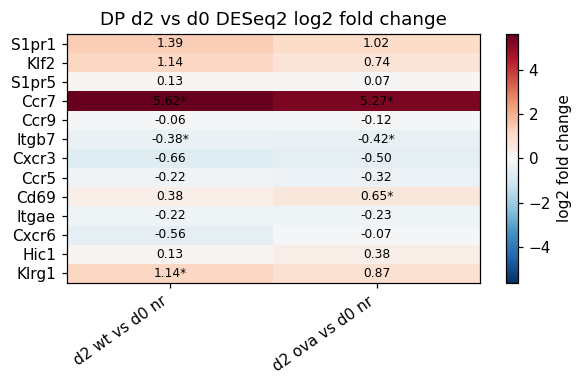

In [12]:
lfc_matrix = deseq_markers.pivot(index="gene", columns="contrast", values="log2FoldChange").reindex(marker_genes)

fig, ax = plt.subplots(figsize=(5.5, 3.6))
max_abs = np.nanmax(np.abs(lfc_matrix.values))
im = ax.imshow(lfc_matrix.values, cmap="RdBu_r", vmin=-max_abs, vmax=max_abs, aspect="auto")

ax.set_xticks(range(lfc_matrix.shape[1]))
ax.set_xticklabels(["d2 wt vs d0 nr", "d2 ova vs d0 nr"], rotation=35, ha="right")
ax.set_yticks(range(lfc_matrix.shape[0]))
ax.set_yticklabels(lfc_matrix.index)
ax.set_title("DP d2 vs d0 DESeq2 log2 fold change")

for i, gene in enumerate(lfc_matrix.index):
    for j, contrast in enumerate(lfc_matrix.columns):
        value = lfc_matrix.loc[gene, contrast]
        padj = deseq_markers.loc[
            deseq_markers["gene"].eq(gene) & deseq_markers["contrast"].eq(contrast), "padj"
        ].iloc[0]
        label = "" if pd.isna(value) else f"{value:.2f}"
        if pd.notna(padj) and padj < 0.05:
            label += "*"
        ax.text(j, i, label, ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("log2 fold change")
fig.tight_layout()
lfc_plot_file = output_dir / "07_bulk_dp_d0_d2_marker_deseq_lfc_heatmap.png"
fig.savefig(lfc_plot_file, bbox_inches="tight")
print("Saved:", lfc_plot_file)


## Quick Interpretation Table


In [13]:
interpretation = deseq_markers.pivot(index="gene", columns="contrast", values="log2FoldChange").reindex(marker_genes)
interpretation.columns = [col.replace("DP_d2_", "d2_").replace("_vs_d0_nr", "_vs_d0") for col in interpretation.columns]
interpretation = interpretation.join(
    expr_summary.pivot(index="gene", columns="condition", values="mean").reindex(marker_genes).add_prefix("mean_log2cpm_")
)
interpretation_file = output_dir / "07_bulk_dp_d0_d2_marker_interpretation_table.tsv"
interpretation.to_csv(interpretation_file, sep="	")
print("Saved:", interpretation_file)
interpretation


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_bulk_dp_d0_d2_marker_interpretation_table.tsv


,d2_ova_vs_d0,d2_wt_vs_d0,mean_log2cpm_DP_nr_d0,mean_log2cpm_DP_wt_d2,mean_log2cpm_DP_ova_d2
gene,,,,,
S1pr1,1.386001,1.023921,1.766661,3.486235,3.763880
Klf2,1.141424,0.739503,5.013259,5.656977,6.001761
S1pr5,0.127761,0.074986,0.000000,0.015949,0.019751
Ccr7,5.618728,5.271013,1.127877,5.111593,5.668147
Ccr9,-0.061046,-0.122903,7.337436,7.031551,6.999890
Itgb7,-0.382749,-0.417923,9.639043,8.859975,8.822097
Cxcr3,-0.664899,-0.503715,7.579082,6.731405,6.472544
Ccr5,-0.215352,-0.322297,8.613120,7.923613,7.875175
Cd69,0.381729,0.650997,9.310488,9.633901,9.264100


## Custom Gene Panel Dot Plot and DESeq2 Layout

This section uses the `custom_genes` list defined near the top of the notebook. Rerun from the top after editing that list to regenerate the expression summaries and DESeq2 layout.

In [14]:
custom_genes_present = [gene for gene in custom_genes if gene in count_matrix.index]
custom_genes_missing = sorted(set(custom_genes).difference(custom_genes_present))

if custom_genes_missing:
    print("Missing genes:", custom_genes_missing)
if not custom_genes_present:
    raise ValueError("None of the custom genes were found in the bulk count matrix")

custom_counts = count_matrix.loc[custom_genes_present, dp_samples].copy()
custom_cpm = custom_counts.div(library_sizes, axis=1) * 1_000_000
custom_log2_cpm = np.log2(custom_cpm + 1)

custom_expr_long = (
    custom_log2_cpm.reset_index(names="gene")
    .melt(id_vars="gene", var_name="sample_id", value_name="log2_cpm")
    .merge(dp_metadata, on="sample_id", how="left")
)

custom_detected_long = (
    custom_cpm.gt(custom_detection_cpm_threshold)
    .reset_index(names="gene")
    .melt(id_vars="gene", var_name="sample_id", value_name="detected")
    .merge(dp_metadata[["sample_id", "condition"]], on="sample_id", how="left")
)

custom_expr_summary = (
    custom_expr_long.groupby(["gene", "condition"], observed=True)["log2_cpm"]
    .agg(mean_log2_cpm="mean", median_log2_cpm="median", sd_log2_cpm="std", n_samples="size")
    .reset_index()
    .merge(
        custom_detected_long.groupby(["gene", "condition"], observed=True)["detected"]
        .mean()
        .mul(100)
        .reset_index(name="pct_detected"),
        on=["gene", "condition"],
        how="left",
    )
)

custom_expr_summary["gene"] = pd.Categorical(custom_expr_summary["gene"], categories=custom_genes_present, ordered=True)
custom_expr_summary["condition"] = pd.Categorical(custom_expr_summary["condition"], categories=condition_order, ordered=True)
custom_expr_summary = custom_expr_summary.sort_values(["gene", "condition"])

custom_expr_file = output_dir / f"07_{custom_panel_name}_expression_summary.tsv"
custom_expr_summary.to_csv(custom_expr_file, sep="	", index=False)
print("Saved:", custom_expr_file)
custom_expr_summary


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_dp_egress_residency_custom_expression_summary.tsv


,gene,condition,mean_log2_cpm,median_log2_cpm,sd_log2_cpm,n_samples,pct_detected
0,Ccr7,DP_nr_d0,1.127877,1.097681,0.624909,3,66.666667
1,Ccr7,DP_wt_d2,5.111593,4.594650,1.077628,5,100.000000
2,Ccr7,DP_ova_d2,5.668147,5.743432,0.537870,4,100.000000
18,S1pr1,DP_nr_d0,1.766661,2.232949,1.585794,3,66.666667
19,S1pr1,DP_wt_d2,3.486235,3.335483,0.586128,5,100.000000
20,S1pr1,DP_ova_d2,3.763880,3.816497,0.149810,4,100.000000
15,Klf2,DP_nr_d0,5.013259,4.612075,0.998606,3,100.000000
16,Klf2,DP_wt_d2,5.656977,5.849534,0.879900,5,100.000000
17,Klf2,DP_ova_d2,6.001761,5.778526,0.616241,4,100.000000
6,Cd69,DP_nr_d0,9.310488,9.369939,0.214267,3,100.000000


In [15]:
custom_deseq_rows = []
for _, row in deseq[deseq["gene_name"].isin(custom_genes_present)].iterrows():
    for contrast in contrast_prefixes:
        custom_deseq_rows.append(
            {
                "gene_id": row["gene_id"],
                "gene": row["gene_name"],
                "contrast": contrast,
                "baseMean": row.get(f"{contrast}__baseMean", np.nan),
                "log2FoldChange": row.get(f"{contrast}__log2FoldChange", np.nan),
                "lfcSE": row.get(f"{contrast}__lfcSE", np.nan),
                "pvalue": row.get(f"{contrast}__pvalue", np.nan),
                "padj": row.get(f"{contrast}__padj", np.nan),
                "significant": row.get(f"{contrast}__significant", np.nan),
            }
        )

custom_deseq = pd.DataFrame(custom_deseq_rows)
custom_deseq["gene"] = pd.Categorical(custom_deseq["gene"], categories=custom_genes_present, ordered=True)
custom_deseq["contrast"] = pd.Categorical(custom_deseq["contrast"], categories=contrast_prefixes, ordered=True)
custom_deseq = custom_deseq.sort_values(["gene", "contrast"])

custom_deseq_file = output_dir / f"07_{custom_panel_name}_deseq_stats.tsv"
custom_deseq.to_csv(custom_deseq_file, sep="	", index=False)
print("Saved:", custom_deseq_file)
custom_deseq


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_dp_egress_residency_custom_deseq_stats.tsv


,gene_id,gene,contrast,baseMean,log2FoldChange,lfcSE,pvalue,padj,significant
6,ENSMUSG00000037944,Ccr7,DP_d2_wt_vs_d0_nr,520.463806,5.271013,0.716942,4.834760e-15,5.875792e-13,True
7,ENSMUSG00000037944,Ccr7,DP_d2_ova_vs_d0_nr,570.179274,5.618728,0.512049,2.071347e-29,1.795127e-26,True
8,ENSMUSG00000045092,S1pr1,DP_d2_wt_vs_d0_nr,146.056282,1.023921,1.054824,4.701081e-02,2.249894e-01,False
9,ENSMUSG00000045092,S1pr1,DP_d2_ova_vs_d0_nr,161.901272,1.386001,1.141199,3.802272e-02,1.778941e-01,False
12,ENSMUSG00000055148,Klf2,DP_d2_wt_vs_d0_nr,868.128832,0.739503,0.534347,7.537128e-02,3.046881e-01,False
13,ENSMUSG00000055148,Klf2,DP_d2_ova_vs_d0_nr,1017.065092,1.141424,0.552970,1.552676e-02,9.142918e-02,False
4,ENSMUSG00000030156,Cd69,DP_d2_wt_vs_d0_nr,12427.997691,0.650997,0.130393,4.067429e-07,1.103492e-05,False
5,ENSMUSG00000030156,Cd69,DP_d2_ova_vs_d0_nr,10797.087606,0.381729,0.191740,4.119717e-02,1.875063e-01,False
0,ENSMUSG00000005947,Itgae,DP_d2_wt_vs_d0_nr,11330.376908,-0.231721,0.148842,1.100175e-01,3.837751e-01,False
1,ENSMUSG00000005947,Itgae,DP_d2_ova_vs_d0_nr,11536.813810,-0.222859,0.147503,1.262427e-01,3.867609e-01,False


/tmp/ipykernel_4174556/1026129264.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_dp_egress_residency_custom_pretty_dotplot_deseq.png
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/07_bulk_von_hoesslin_dp_d0_d2_marker_dynamics/07_dp_egress_residency_custom_pretty_dotplot_deseq.pdf


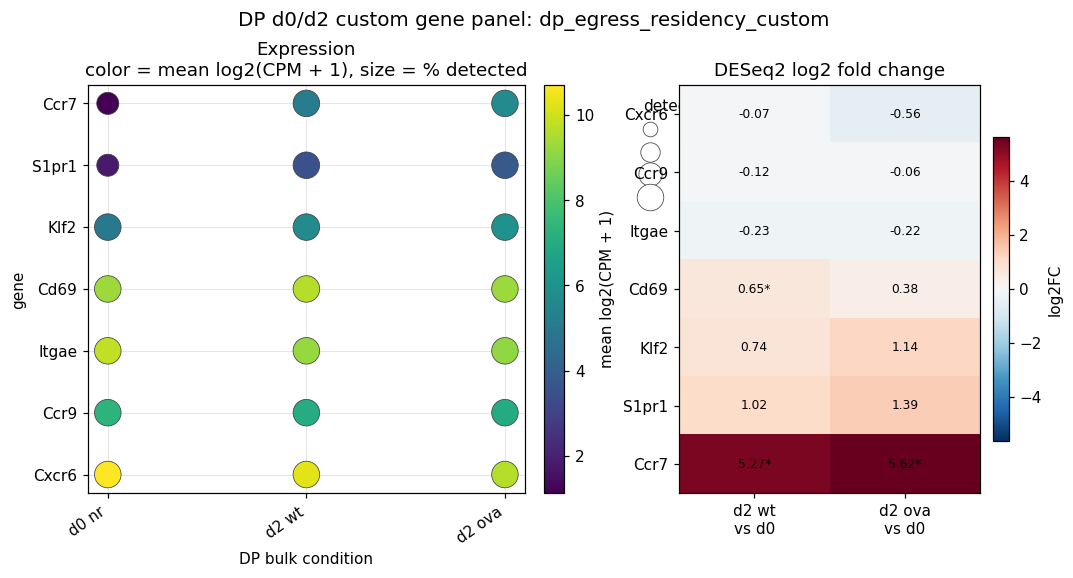

In [16]:
from matplotlib import gridspec

condition_labels = {
    "DP_nr_d0": "d0 nr",
    "DP_wt_d2": "d2 wt",
    "DP_ova_d2": "d2 ova",
}
contrast_labels = {
    "DP_d2_wt_vs_d0_nr": "d2 wt\nvs d0",
    "DP_d2_ova_vs_d0_nr": "d2 ova\nvs d0",
}

genes_for_plot = list(reversed(custom_genes_present))
conditions_for_plot = condition_order
contrasts_for_plot = contrast_prefixes

fig_height = max(4.2, 0.46 * len(genes_for_plot) + 1.6)
fig = plt.figure(figsize=(10.8, fig_height))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.45, 1.0], wspace=0.28)

ax_dot = fig.add_subplot(gs[0, 0])
plot_expr = custom_expr_summary.copy()
plot_expr["gene_plot"] = pd.Categorical(plot_expr["gene"].astype(str), categories=genes_for_plot, ordered=True)
plot_expr["condition_plot"] = pd.Categorical(plot_expr["condition"].astype(str), categories=conditions_for_plot, ordered=True)
plot_expr["x"] = plot_expr["condition_plot"].cat.codes
plot_expr["y"] = plot_expr["gene_plot"].cat.codes

size_values = plot_expr["pct_detected"].fillna(0)
sizes = 22 + (size_values / 100) * 280
scatter = ax_dot.scatter(
    plot_expr["x"],
    plot_expr["y"],
    s=sizes,
    c=plot_expr["mean_log2_cpm"],
    cmap="viridis",
    edgecolor="0.25",
    linewidth=0.5,
)

ax_dot.set_xticks(range(len(conditions_for_plot)))
ax_dot.set_xticklabels([condition_labels[c] for c in conditions_for_plot], rotation=35, ha="right")
ax_dot.set_yticks(range(len(genes_for_plot)))
ax_dot.set_yticklabels(genes_for_plot)
ax_dot.set_xlabel("DP bulk condition")
ax_dot.set_ylabel("gene")
ax_dot.set_title("Expression\ncolor = mean log2(CPM + 1), size = % detected")
ax_dot.grid(axis="both", color="0.9", linewidth=0.7)
ax_dot.set_axisbelow(True)

cbar = fig.colorbar(scatter, ax=ax_dot, fraction=0.046, pad=0.04)
cbar.set_label("mean log2(CPM + 1)")

legend_sizes = [25, 50, 75, 100]
legend_handles = [
    ax_dot.scatter([], [], s=22 + (value / 100) * 280, color="white", edgecolor="0.25", linewidth=0.5)
    for value in legend_sizes
]
ax_dot.legend(
    legend_handles,
    [f"{value}%" for value in legend_sizes],
    title="detected",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.22, 1.0),
)

ax_lfc = fig.add_subplot(gs[0, 1])
lfc_matrix = (
    custom_deseq.pivot(index="gene", columns="contrast", values="log2FoldChange")
    .reindex(index=genes_for_plot, columns=contrasts_for_plot)
)
padj_matrix = (
    custom_deseq.pivot(index="gene", columns="contrast", values="padj")
    .reindex(index=genes_for_plot, columns=contrasts_for_plot)
)

max_abs = np.nanmax(np.abs(lfc_matrix.values)) if np.isfinite(lfc_matrix.values).any() else 1
max_abs = max(max_abs, 0.5)
im = ax_lfc.imshow(lfc_matrix.values, cmap="RdBu_r", vmin=-max_abs, vmax=max_abs, aspect="auto")

ax_lfc.set_xticks(range(len(contrasts_for_plot)))
ax_lfc.set_xticklabels([contrast_labels[c] for c in contrasts_for_plot])
ax_lfc.set_yticks(range(len(genes_for_plot)))
ax_lfc.set_yticklabels(genes_for_plot)
ax_lfc.set_title("DESeq2 log2 fold change")

for i, gene in enumerate(genes_for_plot):
    for j, contrast in enumerate(contrasts_for_plot):
        value = lfc_matrix.loc[gene, contrast]
        padj = padj_matrix.loc[gene, contrast]
        if pd.isna(value):
            label = "NA"
        else:
            label = f"{value:.2f}"
            if pd.notna(padj) and padj < 0.05:
                label += "*"
        ax_lfc.text(j, i, label, ha="center", va="center", fontsize=8)

cbar2 = fig.colorbar(im, ax=ax_lfc, fraction=0.046, pad=0.04)
cbar2.set_label("log2FC")

fig.suptitle(f"DP d0/d2 custom gene panel: {custom_panel_name}", y=1.02, fontsize=13)
fig.tight_layout()

custom_plot_png = output_dir / f"07_{custom_panel_name}_pretty_dotplot_deseq.png"
custom_plot_pdf = output_dir / f"07_{custom_panel_name}_pretty_dotplot_deseq.pdf"
fig.savefig(custom_plot_png, bbox_inches="tight")
fig.savefig(custom_plot_pdf, bbox_inches="tight")
print("Saved:", custom_plot_png)
print("Saved:", custom_plot_pdf)
